In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'SRF gun simulation',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '24',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.310378, valid=0.024524, test=0.024762
	validation loss decreased (inf -> 0.024524), saving model ...
	epoch 2 losses: train=0.239418, valid=0.015865, test=0.015961
	validation loss decreased (0.024524 -> 0.015865), saving model ...
	epoch 3 losses: train=0.108345, valid=0.009910, test=0.009877
	validation loss decreased (0.015865 -> 0.009910), saving model ...
	epoch 4 losses: train=0.074551, valid=0.006922, test=0.007109
	validation loss decreased (0.009910 -> 0.006922), saving model ...
	epoch 5 losses: train=0.058239, valid=0.005616, test=0.005984
	validation loss decreased (0.006922 -> 0.005616), saving model ...
	epoch 6 losses: train=0.023799, valid=0.002281, test=0.002444
	validation loss decreased (0.005616 -> 0.002281), saving model ...
	epoch 7 losses: train=0.014705, valid=0.001870, test=0.002052
	validation loss decreased (0.002281 -> 0.001870), saving model ...
	epoch 8 losses: train=0.013765, valid=0.001931, test=0.00

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

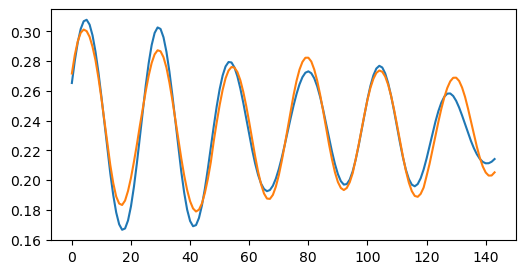

In [7]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [8]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.140834, valid=-0.055374, test=-0.063987
	validation loss decreased (inf -> -0.055374), saving model ...
	epoch 2 losses: train=-0.443507, valid=-0.183044, test=-0.191718
	validation loss decreased (-0.055374 -> -0.183044), saving model ...
	epoch 3 losses: train=-0.633096, valid=-0.227336, test=-0.226473
	validation loss decreased (-0.183044 -> -0.227336), saving model ...
	epoch 4 losses: train=-0.707467, valid=-0.267313, test=-0.268259
	validation loss decreased (-0.227336 -> -0.267313), saving model ...
	epoch 5 losses: train=-0.743363, valid=-0.293054, test=-0.341942
	validation loss decreased (-0.267313 -> -0.293054), saving model ...
	epoch 6 losses: train=-0.781918, valid=-0.133396, test=0.103415
	early stopping counter: 1 out of 10
	epoch 7 losses: train=-0.776790, valid=4.714239, test=17.940096
	early stopping counter: 2 out of 10
	epoch 8 losses: train=-0.834663, valid=0.647294, test=6.385036
	early stopping counte

In [9]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

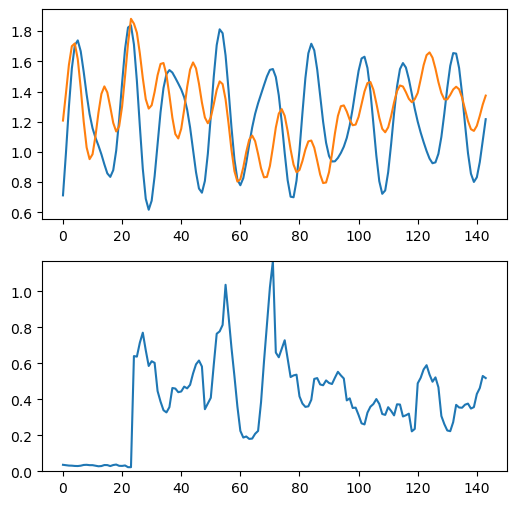

In [10]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [11]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=0.262981, valid=0.213259, test=0.216601
	validation loss decreased (inf -> 0.213259), saving model ...
	epoch 2 losses: train=0.216033, valid=0.152081, test=0.156290
	validation loss decreased (0.213259 -> 0.152081), saving model ...
	epoch 3 losses: train=0.184237, valid=0.148966, test=0.152022
	validation loss decreased (0.152081 -> 0.148966), saving model ...
	epoch 4 losses: train=0.171990, valid=0.098865, test=0.101033
	validation loss decreased (0.148966 -> 0.098865), saving model ...
	epoch 5 losses: train=0.098292, valid=0.070193, test=0.072849
	validation loss decreased (0.098865 -> 0.070193), saving model ...
	epoch 6 losses: train=0.064579, valid=0.063151, test=0.066032
	validation loss decreased (0.070193 -> 0.063151), saving model ...
	epoch 7 losses: train=0.053602, valid=0.061517, test=0.065205
	validation loss decreased (0.063151 -> 0.061517), saving model ...
	epoch 8 losses: train=0.052046, valid=0.061795, test=0.063

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

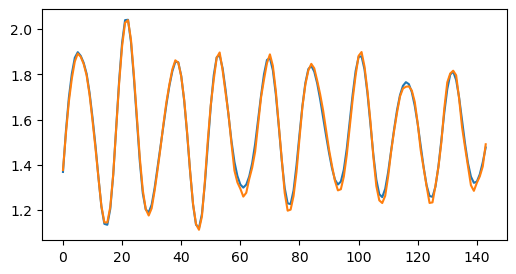

In [13]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [14]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.028908, valid=-0.606979, test=-0.592723
	validation loss decreased (inf -> -0.606979), saving model ...
	epoch 2 losses: train=-0.911614, valid=-0.910354, test=-0.864240
	validation loss decreased (-0.606979 -> -0.910354), saving model ...
	epoch 3 losses: train=-1.168573, valid=-1.030620, test=-0.988472
	validation loss decreased (-0.910354 -> -1.030620), saving model ...
	epoch 4 losses: train=-1.255261, valid=-1.062482, test=-1.023120
	validation loss decreased (-1.030620 -> -1.062482), saving model ...
	epoch 5 losses: train=-1.298847, valid=-1.082835, test=-1.037617
	validation loss decreased (-1.062482 -> -1.082835), saving model ...
	epoch 6 losses: train=-1.321384, valid=-1.117934, test=-1.079777
	validation loss decreased (-1.082835 -> -1.117934), saving model ...
	epoch 7 losses: train=-1.348012, valid=-1.129701, test=-1.097678
	validation loss decreased (-1.117934 -> -1.129701), saving model ...
	epoch 8 losses: tr

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

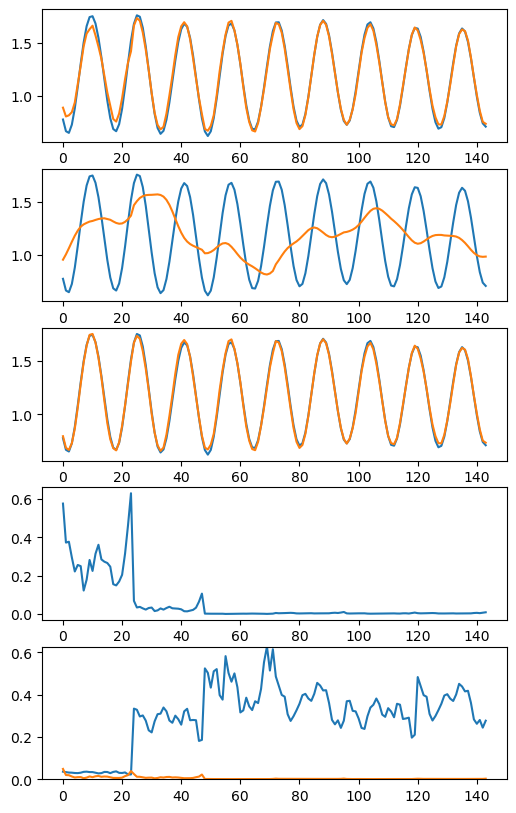

In [22]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break